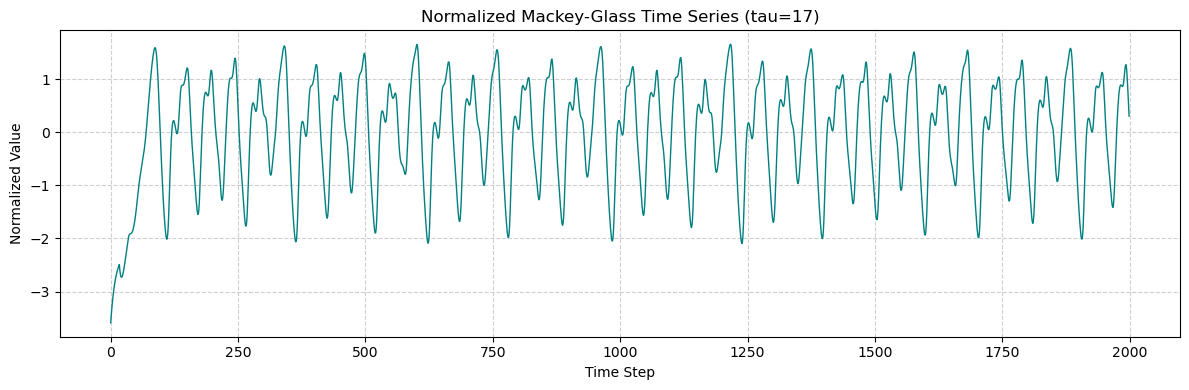

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Define Mackey-Glass Parameters
a = 0.2
b = 0.1
c = 10
tau = 17
n_samples = 2000
dt = 1.0 # Time step

# 2. Generate Time Series using Euler integration
history_len = tau
x = np.zeros(n_samples + history_len)
x[:history_len] = 1.2 # Initial condition

for t in range(history_len, n_samples + history_len - 1):
	x_tau = x[t - tau]
	dx_dt = (a * x_tau) / (1 + x_tau**c) - b * x[t]
	x[t+1] = x[t] + dx_dt * dt

data = x[history_len:]

# 3. Normalize Data (Mean=0, Std=1)
scaler = StandardScaler()
data_norm = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# 4. Split Dataset (70% Train, 15% Val, 15% Test)
train_data, temp_data = train_test_split(data_norm, test_size=0.30, shuffle=False)
val_data, test_data = train_test_split(temp_data, test_size=0.50, shuffle=False)

# Plotting the normalized series
plt.figure(figsize=(12, 4))
plt.plot(data_norm, color='teal', linewidth=1)
plt.title('Normalized Mackey-Glass Time Series (tau=17)')
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('k1.png', dpi=300)
plt.show()

Test RMSE: 0.0806
Test MAE:  0.0644
Test R^2:  0.9920


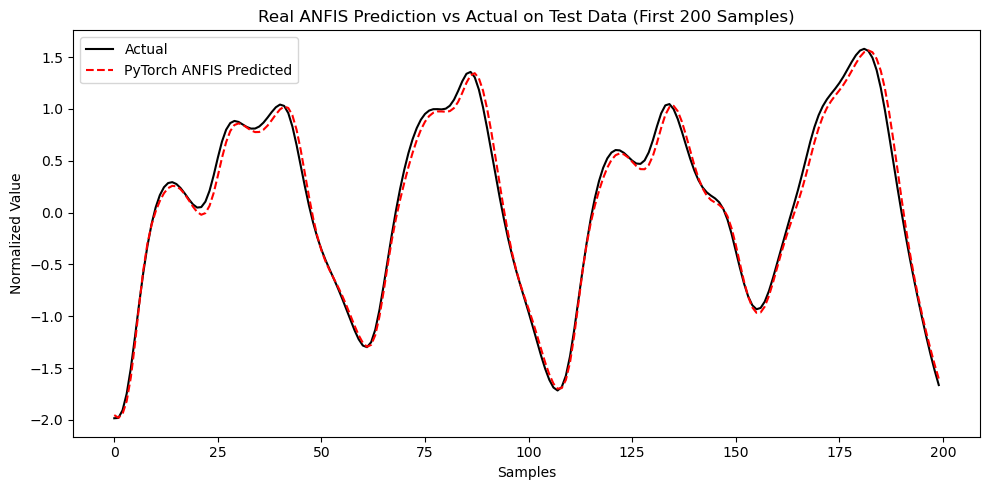

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Prepare Delay Features (delay=3)
def create_dataset(time_series, delay=3):
	X, Y = [], []
	for i in range(len(time_series) - delay):
		X.append(time_series[i:(i + delay)])
		Y.append(time_series[i + delay])
	return np.array(X), np.array(Y)

X_train, Y_train = create_dataset(train_data, delay=3)
X_test, Y_test = create_dataset(test_data, delay=3)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# 2. Define PyTorch ANFIS Model
class PyTorchANFIS(nn.Module):
	def __init__(self):
		super(PyTorchANFIS, self).__init__()
		# Antecedent: 3 inputs, 2 Gaussian MFs each (Centers and Sigmas)
		self.centers = nn.Parameter(torch.randn(3, 2))
		self.sigmas = nn.Parameter(torch.ones(3, 2))
		# Consequent: 8 rules (2^3), 3 linear parameters + 1 bias per rule
		self.consequents = nn.Parameter(torch.randn(8, 4))
		
	def forward(self, x):
		# Layer 1: Fuzzification
		mu_x1 = torch.exp(-((x[:, 0:1] - self.centers[0, :])**2) / (2 * self.sigmas[0, :]**2))
		mu_x2 = torch.exp(-((x[:, 1:2] - self.centers[1, :])**2) / (2 * self.sigmas[1, :]**2))
		mu_x3 = torch.exp(-((x[:, 2:3] - self.centers[2, :])**2) / (2 * self.sigmas[2, :]**2))
		
		# Layer 2 & 3: Rule Firing Strength and Normalization
		w = []
		for i in range(2):
			for j in range(2):
				for k in range(2):
					w.append(mu_x1[:, i] * mu_x2[:, j] * mu_x3[:, k])
		w = torch.stack(w, dim=1)
		w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-8)
		
		# Layer 4 & 5: Consequent Evaluation and Defuzzification
		batch_size = x.size(0)
		x_pad = torch.cat([x, torch.ones(batch_size, 1)], dim=1)
		out = 0
		for rule_idx in range(8):
			f_k = torch.sum(x_pad * self.consequents[rule_idx, :], dim=1)
			out += w_norm[:, rule_idx] * f_k
			
		return out.view(-1, 1)

# 3. Model Initialization and Training
model = PyTorchANFIS()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200
for epoch in range(epochs):
	model.train()
	optimizer.zero_grad()
	predictions = model(X_train_t)
	loss = criterion(predictions, Y_train_t)
	loss.backward()
	optimizer.step()

# 4. Evaluation and Predictions
model.eval()
with torch.no_grad():
	Y_pred_test = model(X_test_t).numpy().flatten()

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
mae = mean_absolute_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test R^2:  {r2:.4f}")

# 5. Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(Y_test[:200], label='Actual', color='black', linewidth=1.5)
plt.plot(Y_pred_test[:200], label='PyTorch ANFIS Predicted', color='red', linestyle='--')
plt.title('Real ANFIS Prediction vs Actual on Test Data (First 200 Samples)')
plt.xlabel('Samples')
plt.ylabel('Normalized Value')
plt.legend()
plt.tight_layout()
plt.savefig('k2.png', dpi=300)
plt.show()